# 03. EDA local con SparkSQL

Lee datasets trusted locales y genera tablas refined en Parquet/CSV.

In [1]:
%run ./00_configuracion.py

PROJECT_DIR: /Users/momos/Downloads/tcga
RAW_DIR: /Users/momos/Downloads/tcga/raw
RAW_METADATA_FILE: /Users/momos/Downloads/tcga/raw/metadata/metadatos_tcga_oficial_18_clases.csv
RAW_RNASEQ_PATH: /Users/momos/Downloads/tcga/raw/rnaseq
LOCAL_DATA_DIR: /Users/momos/Downloads/tcga/data_local


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/06 17:52:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 4.1.2


In [2]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

df_trusted = read_trusted(TRUSTED_LONG_PATH)
df_samples = read_trusted(TRUSTED_SAMPLES_PATH)
df_genes = read_trusted(TRUSTED_GENES_PATH)

df_trusted.createOrReplaceTempView("trusted_long")
df_samples.createOrReplaceTempView("trusted_samples")
df_genes.createOrReplaceTempView("trusted_genes")

print("Registros long:", df_trusted.count())
print("Muestras:", df_samples.count())
print("Genes:", df_genes.count())
mostrar(df_trusted, 5)

Registros long: 166233240
Muestras: 8335
Genes: 19944


,file_id,file_name,file_size,case_id,case_submitter_id,sample_id,sample_submitter_id,patient_id,sample_type,project_id,cancer_name,gene_id_base,gene_name,gene_type,tpm_unstranded,log2_tpm,source_file,cancer_type
0,1ba64243-b3c1-4b6b-9899-64944a3da9ab,0c097ee8-b601-4262-b2b6-d30cfd4c858f.rna_seq.a...,4232015,a40f1055-3dc4-4d01-930c-92cf314f73f8,TCGA-HD-7917,fd10c460-8f6a-4748-a422-b00f9fb5adc0,TCGA-HD-7917-01A,TCGA-HD-7917,Primary Tumor,TCGA-HNSC,Head and neck squamous cell carcinoma,ENSG00000000003,TSPAN6,protein_coding,32.3058,5.057702,file:///Users/momos/Downloads/notebooks_locale...,HNSC
1,34e3a8ec-b5c4-45e7-8370-fda9d20deaec,8e78d4b9-7fc2-41e1-9d56-d4435e062ca3.rna_seq.a...,4203298,dec3c21b-3f59-472f-8573-27b0e830aa92,TCGA-HD-A6I0,eda02789-debf-496c-919f-16a4f96f8307,TCGA-HD-A6I0-01A,TCGA-HD-A6I0,Primary Tumor,TCGA-HNSC,Head and neck squamous cell carcinoma,ENSG00000172288,CDY1,protein_coding,0.0000,0.000000,file:///Users/momos/Downloads/notebooks_locale...,HNSC
2,1ba64243-b3c1-4b6b-9899-64944a3da9ab,0c097ee8-b601-4262-b2b6-d30cfd4c858f.rna_seq.a...,4232015,a40f1055-3dc4-4d01-930c-92cf314f73f8,TCGA-HD-7917,fd10c460-8f6a-4748-a422-b00f9fb5adc0,TCGA-HD-7917-01A,TCGA-HD-7917,Primary Tumor,TCGA-HNSC,Head and neck squamous cell carcinoma,ENSG00000000005,TNMD,protein_coding,0.0000,0.000000,file:///Users/momos/Downloads/notebooks_locale...,HNSC
3,34e3a8ec-b5c4-45e7-8370-fda9d20deaec,8e78d4b9-7fc2-41e1-9d56-d4435e062ca3.rna_seq.a...,4203298,dec3c21b-3f59-472f-8573-27b0e830aa92,TCGA-HD-A6I0,eda02789-debf-496c-919f-16a4f96f8307,TCGA-HD-A6I0-01A,TCGA-HD-A6I0,Primary Tumor,TCGA-HNSC,Head and neck squamous cell carcinoma,ENSG00000172289,OR10V1,protein_coding,0.0000,0.000000,file:///Users/momos/Downloads/notebooks_locale...,HNSC
4,1ba64243-b3c1-4b6b-9899-64944a3da9ab,0c097ee8-b601-4262-b2b6-d30cfd4c858f.rna_seq.a...,4232015,a40f1055-3dc4-4d01-930c-92cf314f73f8,TCGA-HD-7917,fd10c460-8f6a-4748-a422-b00f9fb5adc0,TCGA-HD-7917-01A,TCGA-HD-7917,Primary Tumor,TCGA-HNSC,Head and neck squamous cell carcinoma,ENSG00000000419,DPM1,protein_coding,133.6231,7.072782,file:///Users/momos/Downloads/notebooks_locale...,HNSC


In [3]:
eda_resumen_general = spark.sql("""
    SELECT
        (SELECT COUNT(*) FROM trusted_long) AS n_registros_long,
        (SELECT COUNT(DISTINCT sample_id) FROM trusted_long) AS n_muestras_long,
        (SELECT COUNT(*) FROM trusted_samples) AS n_filas_samples,
        (SELECT COUNT(DISTINCT sample_id) FROM trusted_samples) AS n_muestras_samples,
        (SELECT COUNT(DISTINCT patient_id) FROM trusted_long) AS n_pacientes,
        (SELECT COUNT(DISTINCT cancer_type) FROM trusted_long) AS n_clases,
        (SELECT COUNT(DISTINCT gene_id_base) FROM trusted_long) AS n_genes_long,
        (SELECT COUNT(DISTINCT gene_id_base) FROM trusted_genes) AS n_genes_diccionario
""")
mostrar(eda_resumen_general)
save_spark_table(eda_resumen_general, "refined_eda_resumen_general")

,n_registros_long,n_muestras_long,n_filas_samples,n_muestras_samples,n_pacientes,n_clases,n_genes_long,n_genes_diccionario
0,166233240,8335,8335,8335,8283,18,19944,19944


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_resumen_general


PosixPath('/Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_resumen_general')

,cancer_type,cancer_name,n_muestras,n_pacientes
0,BRCA,Breast invasive carcinoma,1106,1095
1,UCEC,Uterine corpus endometrial carcinoma,549,545
2,KIRC,Kidney renal clear cell carcinoma,537,533
3,LUAD,Lung adenocarcinoma,529,517
4,HNSC,Head and neck squamous cell carcinoma,520,520
5,LGG,Brain lower grade glioma,516,516
6,THCA,Thyroid carcinoma,505,505
7,PRAD,Prostate adenocarcinoma,501,497
8,LUSC,Lung squamous cell carcinoma,501,501
9,COAD,Colon adenocarcinoma,471,458


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_conteo_clases


,cancer_type,n_muestras,porcentaje,razon_desbalance_global
0,BRCA,1106,13.27,10.74
1,UCEC,549,6.59,10.74
2,KIRC,537,6.44,10.74
3,LUAD,529,6.35,10.74
4,HNSC,520,6.24,10.74
5,LGG,516,6.19,10.74
6,THCA,505,6.06,10.74
7,PRAD,501,6.01,10.74
8,LUSC,501,6.01,10.74
9,COAD,471,5.65,10.74


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_desbalance_clases
Figura guardada: /Users/momos/Downloads/tcga/data_local/refined/visualizations/distribucion_clases.png


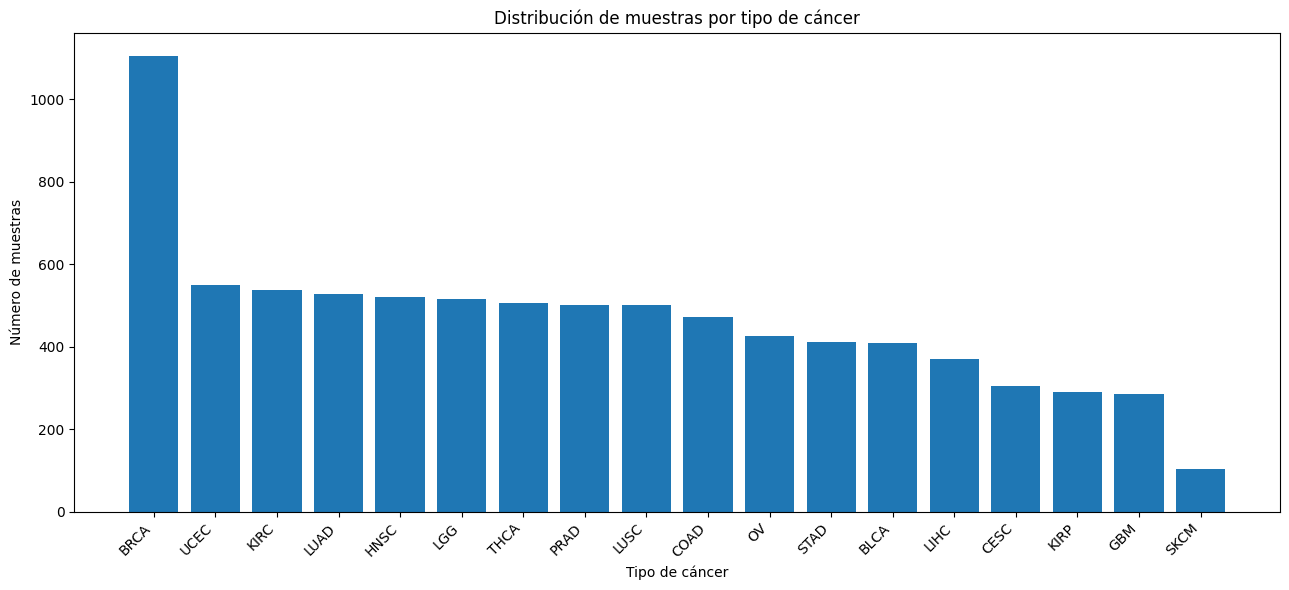

In [4]:
eda_conteo_clases = spark.sql("""
    SELECT cancer_type, cancer_name,
           COUNT(DISTINCT sample_id) AS n_muestras,
           COUNT(DISTINCT patient_id) AS n_pacientes
    FROM trusted_long
    GROUP BY cancer_type, cancer_name
    ORDER BY n_muestras DESC
""")
mostrar(eda_conteo_clases, 30)
save_spark_table(eda_conteo_clases, "refined_eda_conteo_clases")

eda_desbalance_clases = spark.sql("""
    WITH conteo AS (
        SELECT cancer_type, COUNT(DISTINCT sample_id) AS n_muestras
        FROM trusted_long GROUP BY cancer_type
    ),
    total AS (SELECT SUM(n_muestras) AS total_muestras FROM conteo),
    extremos AS (SELECT MAX(n_muestras) AS max_muestras, MIN(n_muestras) AS min_muestras FROM conteo)
    SELECT c.cancer_type, c.n_muestras,
           ROUND(100 * c.n_muestras / t.total_muestras, 2) AS porcentaje,
           ROUND(e.max_muestras / e.min_muestras, 2) AS razon_desbalance_global
    FROM conteo c CROSS JOIN total t CROSS JOIN extremos e
    ORDER BY c.n_muestras DESC
""")
mostrar(eda_desbalance_clases, 30)
save_spark_table(eda_desbalance_clases, "refined_eda_desbalance_clases")

pdf = eda_conteo_clases.toPandas()
plt.figure(figsize=(13,6))
plt.bar(pdf["cancer_type"], pdf["n_muestras"])
plt.title("Distribución de muestras por tipo de cáncer")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Número de muestras")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
guardar_figura("distribucion_clases.png")
plt.show()

In [5]:
eda_calidad_datos = spark.sql("""
    SELECT cancer_type,
           COUNT(*) AS n_registros,
           SUM(CASE WHEN log2_tpm IS NULL THEN 1 ELSE 0 END) AS n_log2_tpm_null,
           SUM(CASE WHEN tpm_unstranded IS NULL THEN 1 ELSE 0 END) AS n_tpm_null,
           SUM(CASE WHEN tpm_unstranded = 0 THEN 1 ELSE 0 END) AS n_tpm_cero,
           ROUND(100 * SUM(CASE WHEN tpm_unstranded = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_tpm_cero
    FROM trusted_long
    GROUP BY cancer_type
    ORDER BY pct_tpm_cero DESC
""")
mostrar(eda_calidad_datos, 30)
save_spark_table(eda_calidad_datos, "refined_eda_calidad_datos")

eda_sample_type = spark.sql("""
    SELECT sample_type, COUNT(DISTINCT sample_id) AS n_muestras, COUNT(DISTINCT patient_id) AS n_pacientes
    FROM trusted_long
    GROUP BY sample_type
    ORDER BY n_muestras DESC
""")
mostrar(eda_sample_type)
save_spark_table(eda_sample_type, "refined_eda_tipos_muestra")

,cancer_type,n_registros,n_log2_tpm_null,n_tpm_null,n_tpm_cero,pct_tpm_cero
0,LIHC,7399224,0,0,1252939,16.93
1,COAD,9393624,0,0,1491284,15.88
2,SKCM,2054232,0,0,312746,15.22
3,KIRP,5783760,0,0,845378,14.62
4,BLCA,8157096,0,0,1183339,14.51
5,THCA,10071720,0,0,1440134,14.30
6,UCEC,10949256,0,0,1564793,14.29
7,CESC,6062976,0,0,862836,14.23
8,HNSC,10370880,0,0,1429009,13.78
9,BRCA,22058064,0,0,2979515,13.51


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_calidad_datos


,sample_type,n_muestras,n_pacientes
0,Primary Tumor,8335,8283


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_tipos_muestra


PosixPath('/Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_tipos_muestra')

,cancer_type,n_registros,media_log2_tpm,sd_log2_tpm,min_log2_tpm,q1_log2_tpm,mediana_log2_tpm,q3_log2_tpm,max_log2_tpm
0,BLCA,8157096,2.7141,2.4384,0.0,0.2190,2.4941,4.5329,16.9432
1,BRCA,22058064,2.9268,2.4747,0.0,0.3188,2.8864,4.8168,18.0636
2,CESC,6062976,2.7869,2.4752,0.0,0.2192,2.6250,4.6595,17.3240
3,COAD,9393624,2.7734,2.4603,0.0,0.2343,2.5997,4.6325,16.7840
4,GBM,5684040,2.8469,2.3173,0.0,0.4755,2.8226,4.5664,16.0216
5,HNSC,10370880,2.7216,2.4515,0.0,0.2216,2.4937,4.5500,16.5445
6,KIRC,10709928,2.7826,2.3894,0.0,0.2845,2.7047,4.5638,16.9897
7,KIRP,5783760,2.6400,2.3709,0.0,0.2056,2.4275,4.4066,17.4248
8,LGG,10291104,2.9584,2.4237,0.0,0.3980,2.9864,4.8030,17.1992
9,LIHC,7399224,2.3130,2.3236,0.0,0.1033,1.8120,3.8948,17.4027


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_expresion_global
Figura guardada: /Users/momos/Downloads/tcga/data_local/refined/visualizations/expresion_promedio_por_clase.png


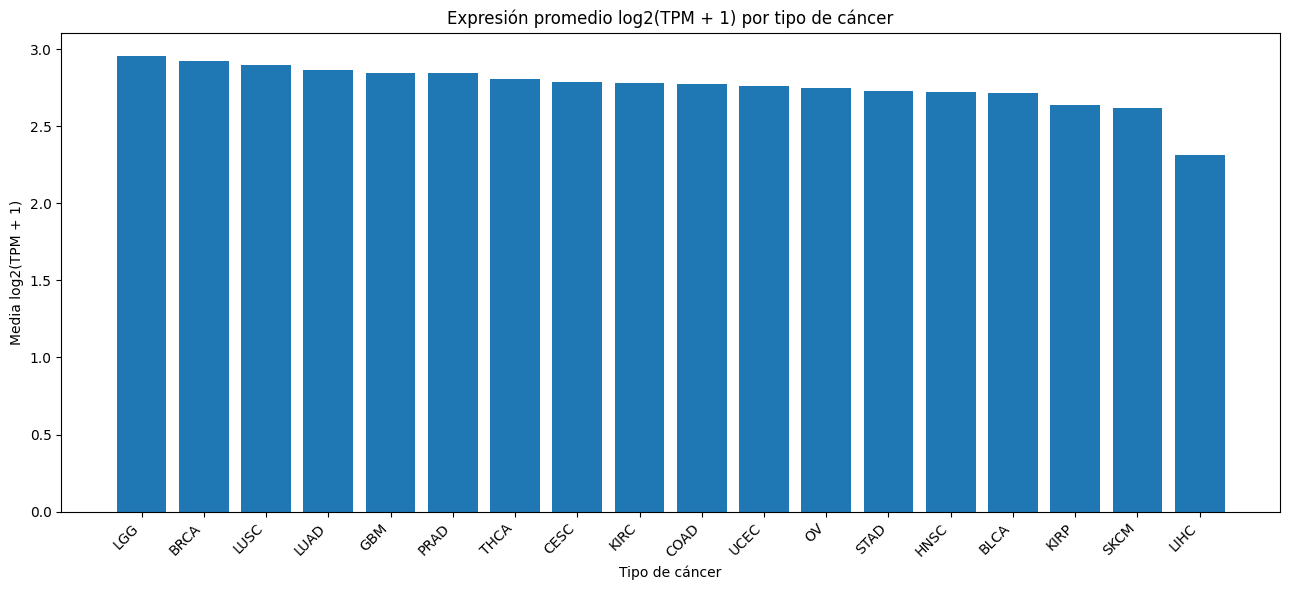

In [6]:
eda_expresion_global = spark.sql("""
    SELECT cancer_type,
           COUNT(*) AS n_registros,
           ROUND(AVG(log2_tpm), 4) AS media_log2_tpm,
           ROUND(STDDEV(log2_tpm), 4) AS sd_log2_tpm,
           ROUND(MIN(log2_tpm), 4) AS min_log2_tpm,
           ROUND(percentile_approx(log2_tpm, 0.25), 4) AS q1_log2_tpm,
           ROUND(percentile_approx(log2_tpm, 0.50), 4) AS mediana_log2_tpm,
           ROUND(percentile_approx(log2_tpm, 0.75), 4) AS q3_log2_tpm,
           ROUND(MAX(log2_tpm), 4) AS max_log2_tpm
    FROM trusted_long
    GROUP BY cancer_type
    ORDER BY cancer_type
""")
mostrar(eda_expresion_global, 30)
save_spark_table(eda_expresion_global, "refined_eda_expresion_global")

pdf_expr = eda_expresion_global.toPandas().sort_values("media_log2_tpm", ascending=False)
plt.figure(figsize=(13,6))
plt.bar(pdf_expr["cancer_type"], pdf_expr["media_log2_tpm"])
plt.title("Expresión promedio log2(TPM + 1) por tipo de cáncer")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Media log2(TPM + 1)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
guardar_figura("expresion_promedio_por_clase.png")
plt.show()

## Distribución de la expresión: cruda vs. log2

Se compara la distribución del TPM crudo frente a `log2(TPM + 1)` para justificar la transformación logarítmica usada en el modelado. El TPM crudo presenta una fuerte asimetría a la derecha (pocos genes con expresión muy alta), mientras que la escala logarítmica estabiliza la varianza y aproxima una forma simétrica. Se cuantifica con asimetría y curtosis sobre toda la tabla larga, y se acompaña de histogramas y un boxplot de `log2(TPM + 1)` por tipo de cáncer.

26/06/06 17:57:57 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,media_tpm,sd_tpm,asimetria_tpm,curtosis_tpm,media_log2,sd_log2,asimetria_log2,curtosis_log2,pct_tpm_cero
0,44.8061,576.7646,66.687,7153.0334,2.7907,2.4227,0.5557,-0.3224,13.56


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_distribucion_expresion


Muestra para histogramas: 300000 registros
Figura guardada: /Users/momos/Downloads/tcga/data_local/refined/visualizations/distribucion_expresion_cruda_vs_log.png


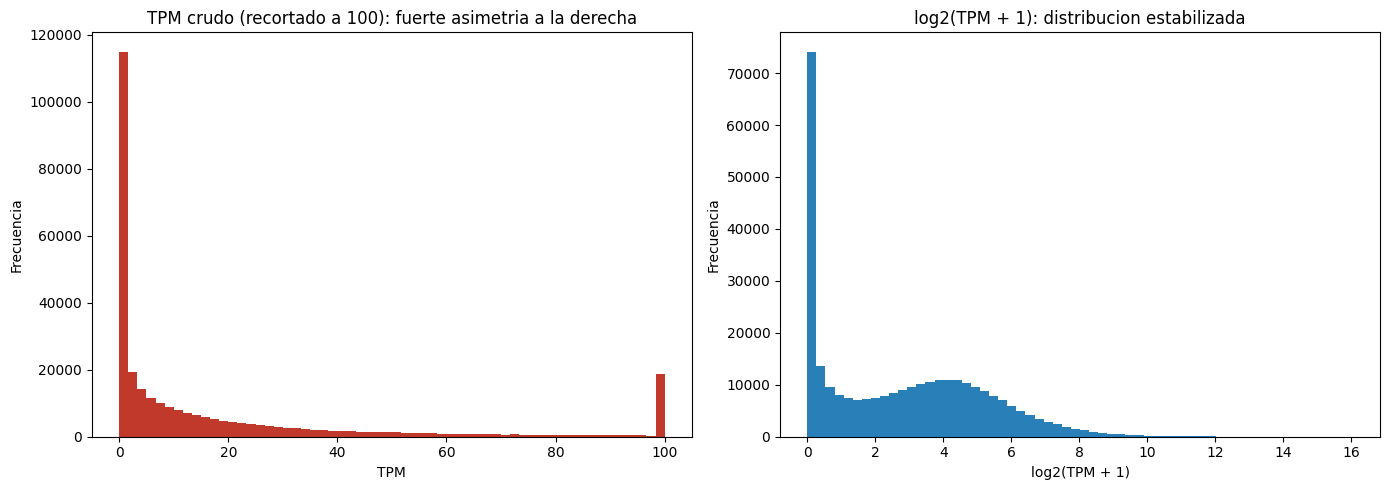

/var/folders/0b/k_lqwpk93dl4nnw4glx67vgh0000gn/T/ipykernel_23260/1731916009.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_box, labels=orden, showfliers=False)


Figura guardada: /Users/momos/Downloads/tcga/data_local/refined/visualizations/boxplot_log2_tpm_por_clase.png


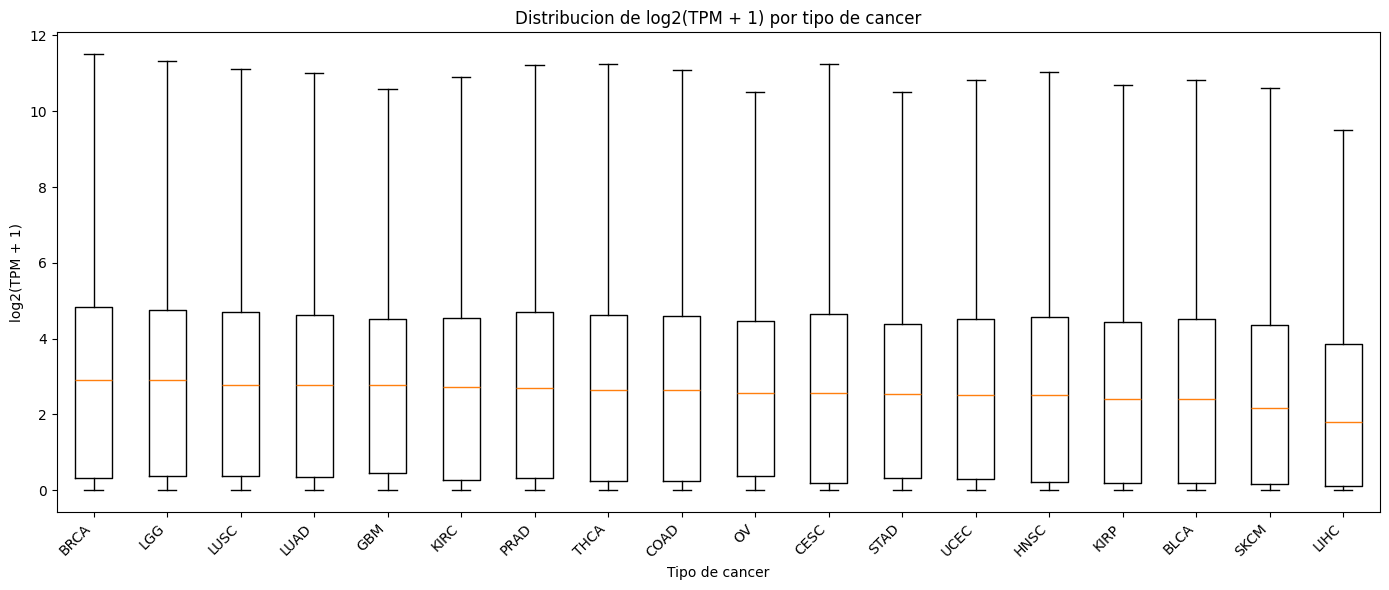

In [7]:
# === Distribución de expresión: cruda vs log2 (justifica la transformación logarítmica) ===
# Estadísticos de forma sobre toda la tabla larga
eda_distribucion_expresion = spark.sql("""
    SELECT
        ROUND(AVG(tpm_unstranded), 4)      AS media_tpm,
        ROUND(STDDEV(tpm_unstranded), 4)   AS sd_tpm,
        ROUND(skewness(tpm_unstranded), 4) AS asimetria_tpm,
        ROUND(kurtosis(tpm_unstranded), 4) AS curtosis_tpm,
        ROUND(AVG(log2_tpm), 4)            AS media_log2,
        ROUND(STDDEV(log2_tpm), 4)         AS sd_log2,
        ROUND(skewness(log2_tpm), 4)       AS asimetria_log2,
        ROUND(kurtosis(log2_tpm), 4)       AS curtosis_log2,
        ROUND(100 * AVG(CASE WHEN tpm_unstranded = 0 THEN 1 ELSE 0 END), 2) AS pct_tpm_cero
    FROM trusted_long
""")
mostrar(eda_distribucion_expresion)
save_spark_table(eda_distribucion_expresion, "refined_eda_distribucion_expresion")

# Muestra para los histogramas (la tabla larga es demasiado grande para traerla completa)
frac_hist = float(os.getenv("TCGA_FRAC_HIST_EDA", "0.01"))
pdf_hist = (spark.table("trusted_long")
            .select("cancer_type", "tpm_unstranded", "log2_tpm")
            .sample(withReplacement=False, fraction=frac_hist, seed=42)
            .toPandas())
if len(pdf_hist) > 300000:
    pdf_hist = pdf_hist.sample(300000, random_state=42)
print("Muestra para histogramas:", len(pdf_hist), "registros")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pdf_hist["tpm_unstranded"].clip(upper=100), bins=60, color="#c0392b")
axes[0].set_title("TPM crudo (recortado a 100): fuerte asimetria a la derecha")
axes[0].set_xlabel("TPM"); axes[0].set_ylabel("Frecuencia")
axes[1].hist(pdf_hist["log2_tpm"], bins=60, color="#2980b9")
axes[1].set_title("log2(TPM + 1): distribucion estabilizada")
axes[1].set_xlabel("log2(TPM + 1)"); axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
guardar_figura("distribucion_expresion_cruda_vs_log.png")
plt.show()

# Boxplot de log2(TPM + 1) por tipo de cancer
orden = (pdf_hist.groupby("cancer_type")["log2_tpm"].median()
         .sort_values(ascending=False).index.tolist())
datos_box = [pdf_hist.loc[pdf_hist["cancer_type"] == c, "log2_tpm"].values for c in orden]
plt.figure(figsize=(14, 6))
plt.boxplot(datos_box, labels=orden, showfliers=False)
plt.title("Distribucion de log2(TPM + 1) por tipo de cancer")
plt.xlabel("Tipo de cancer"); plt.ylabel("log2(TPM + 1)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
guardar_figura("boxplot_log2_tpm_por_clase.png")
plt.show()


,gene_id_base,gene_name,media_global,sd_entre_clases,rango_entre_clases
0,ENSG00000186081,KRT5,4.2050,4.1065,12.7183
1,ENSG00000205420,KRT6A,3.5508,4.0200,13.1138
2,ENSG00000131095,GFAP,1.5960,3.7202,12.0203
3,ENSG00000186847,KRT14,3.4405,3.7129,13.2014
4,ENSG00000171345,KRT19,7.4272,3.6698,10.8292
5,ENSG00000128422,KRT17,5.4172,3.5482,11.5008
6,ENSG00000186832,KRT16,3.3248,3.4757,11.6363
7,ENSG00000106541,AGR2,4.6444,3.4261,9.3694
8,ENSG00000165215,CLDN3,5.7599,3.3938,9.9525
9,ENSG00000168878,SFTPB,1.7342,3.3306,11.1189


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_genes_mas_variables


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_top_genes_por_clase


Figura guardada: /Users/momos/Downloads/tcga/data_local/refined/visualizations/top20_genes_variables.png


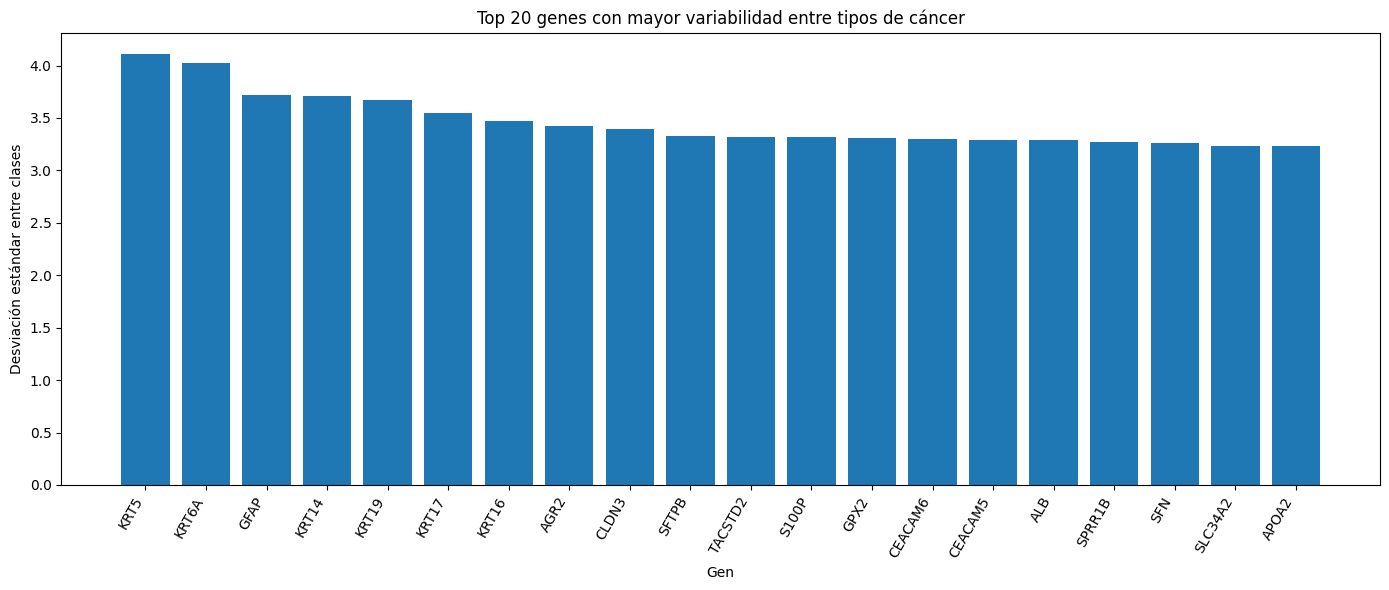

In [8]:
TOP_GENES_VARIABLES = int(os.getenv("TCGA_TOP_GENES_VARIABLES_EDA", "5000"))

eda_genes_mas_variables = spark.sql(f"""
    WITH media_por_clase AS (
        SELECT gene_id_base, gene_name, cancer_type, AVG(log2_tpm) AS media_clase
        FROM trusted_long
        GROUP BY gene_id_base, gene_name, cancer_type
    ),
    variabilidad AS (
        SELECT gene_id_base, gene_name,
               AVG(media_clase) AS media_global,
               STDDEV(media_clase) AS sd_entre_clases,
               MAX(media_clase) - MIN(media_clase) AS rango_entre_clases
        FROM media_por_clase
        GROUP BY gene_id_base, gene_name
    )
    SELECT gene_id_base, gene_name,
           ROUND(media_global, 4) AS media_global,
           ROUND(sd_entre_clases, 4) AS sd_entre_clases,
           ROUND(rango_entre_clases, 4) AS rango_entre_clases
    FROM variabilidad
    ORDER BY sd_entre_clases DESC
    LIMIT {TOP_GENES_VARIABLES}
""")
mostrar(eda_genes_mas_variables, 30)
save_spark_table(eda_genes_mas_variables, "refined_eda_genes_mas_variables")

eda_top_genes_por_clase = spark.sql("""
    WITH expresion_gen AS (
        SELECT cancer_type, gene_id_base, gene_name, AVG(log2_tpm) AS avg_log2_tpm
        FROM trusted_long
        GROUP BY cancer_type, gene_id_base, gene_name
    ),
    ranking AS (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY cancer_type ORDER BY avg_log2_tpm DESC) AS rank_gen
        FROM expresion_gen
    )
    SELECT cancer_type, rank_gen, gene_id_base, gene_name, ROUND(avg_log2_tpm, 4) AS avg_log2_tpm
    FROM ranking
    WHERE rank_gen <= 10
    ORDER BY cancer_type, rank_gen
""")
save_spark_table(eda_top_genes_por_clase, "refined_eda_top_genes_por_clase")

pdf_genes = eda_genes_mas_variables.limit(20).toPandas()
plt.figure(figsize=(14,6))
plt.bar(pdf_genes["gene_name"], pdf_genes["sd_entre_clases"])
plt.title("Top 20 genes con mayor variabilidad entre tipos de cáncer")
plt.xlabel("Gen")
plt.ylabel("Desviación estándar entre clases")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
guardar_figura("top20_genes_variables.png")
plt.show()

## Control de efectos de lote (batch effects)

TCGA no expone aqui variables tecnicas explicitas (placa, centro o fecha de secuenciacion), pero el *barcode* `TCGA-TSS-...` codifica el **Tissue Source Site (TSS)**, el centro de origen de la muestra, que funciona como proxy de lote. Se evalua hasta que punto el TSS esta confundido con la variable objetivo `cancer_type`:

- **Diversidad dentro de la clase**: cuantos centros distintos aporta cada tipo de cancer y que peso tiene el centro dominante. Mucha diversidad y baja dominancia implica que el modelo no puede apoyarse en un atajo del tipo "un centro = un cancer".
- **Solapamiento entre clases**: cuantos TSS contribuyen a mas de un tipo de cancer. En TCGA el codigo TSS es especifico de enfermedad, por lo que queda anidado dentro de la clase y **no permite separar la senal tecnica de la biologica**. Esto no invalida el modelo, pero si justifica que la verificacion definitiva de ausencia de batch effects requiera variables tecnicas adicionales (placa/centro) o cohortes externas independientes.

,cancer_type,n_muestras,n_centros_tss,n_centro_dominante,pct_centro_dominante
0,GBM,285,14,110,38.60
1,SKCM,103,16,45,43.69
2,OV,426,20,90,21.13
3,KIRC,537,20,142,26.44
4,STAD,412,22,130,31.55
5,THCA,505,22,92,18.22
6,COAD,471,25,172,36.52
7,LGG,516,26,104,20.16
8,HNSC,520,28,135,25.96
9,UCEC,549,31,78,14.21


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_batch_centros_por_clase


,n_tss_total,n_tss_compartidos,n_tss_exclusivos,pct_muestras_en_tss_exclusivo
0,501,0,501,100.0


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_batch_solapamiento_tss
Figura guardada: /Users/momos/Downloads/tcga/data_local/refined/visualizations/batch_centros_tss_por_clase.png


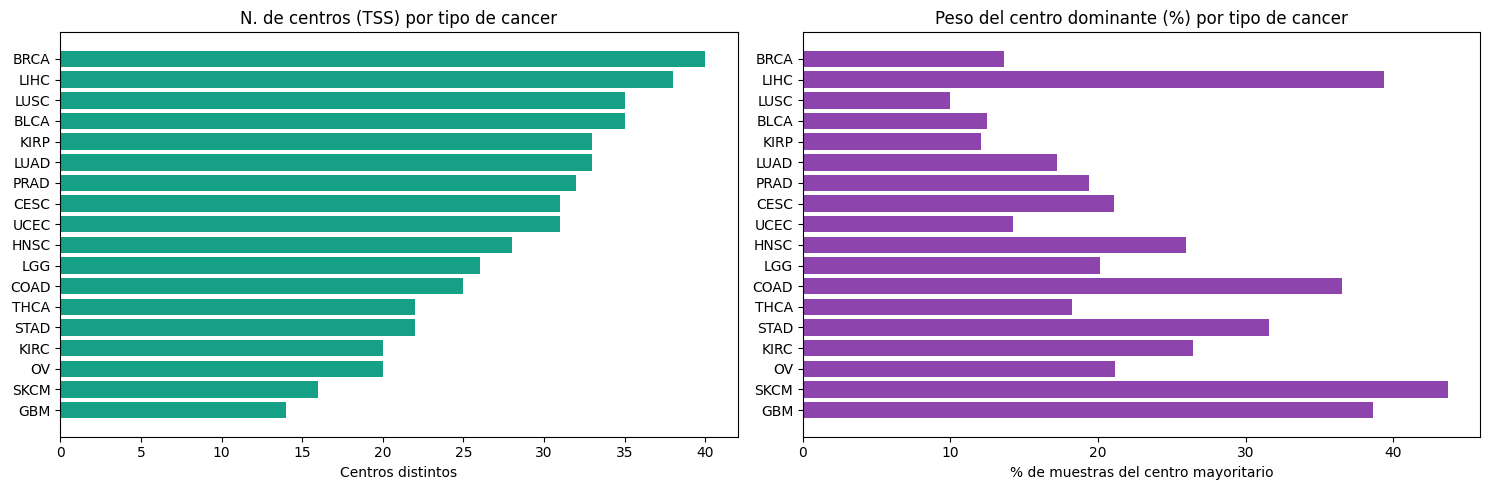

In [9]:
# === Efectos de lote: Tissue Source Site (TSS) como proxy de centro/lote ===
spark.sql("""
    CREATE OR REPLACE TEMP VIEW samples_tss AS
    SELECT *, split(case_submitter_id, '-')[1] AS tss_code
    FROM trusted_samples
""")

# Diversidad de centros dentro de cada tipo de cancer
eda_batch_centros_por_clase = spark.sql("""
    WITH por_clase_tss AS (
        SELECT cancer_type, tss_code, COUNT(DISTINCT sample_id) AS n
        FROM samples_tss GROUP BY cancer_type, tss_code
    ),
    tot AS (
        SELECT cancer_type,
               COUNT(DISTINCT sample_id) AS n_muestras,
               COUNT(DISTINCT tss_code)  AS n_centros_tss
        FROM samples_tss GROUP BY cancer_type
    ),
    dom AS (
        SELECT cancer_type, MAX(n) AS n_centro_dominante
        FROM por_clase_tss GROUP BY cancer_type
    )
    SELECT t.cancer_type, t.n_muestras, t.n_centros_tss,
           d.n_centro_dominante,
           ROUND(100 * d.n_centro_dominante / t.n_muestras, 2) AS pct_centro_dominante
    FROM tot t JOIN dom d USING (cancer_type)
    ORDER BY n_centros_tss ASC
""")
mostrar(eda_batch_centros_por_clase, 30)
save_spark_table(eda_batch_centros_por_clase, "refined_eda_batch_centros_por_clase")

# Solapamiento de TSS entre tipos de cancer (capacidad de deconfundir lote vs biologia)
eda_batch_solapamiento_tss = spark.sql("""
    WITH tss_span AS (
        SELECT tss_code,
               COUNT(DISTINCT sample_id)   AS n_muestras,
               COUNT(DISTINCT cancer_type) AS n_tipos_cancer
        FROM samples_tss GROUP BY tss_code
    )
    SELECT
        COUNT(*) AS n_tss_total,
        SUM(CASE WHEN n_tipos_cancer > 1 THEN 1 ELSE 0 END) AS n_tss_compartidos,
        SUM(CASE WHEN n_tipos_cancer = 1 THEN 1 ELSE 0 END) AS n_tss_exclusivos,
        ROUND(100 * SUM(CASE WHEN n_tipos_cancer = 1 THEN n_muestras ELSE 0 END)
              / SUM(n_muestras), 2) AS pct_muestras_en_tss_exclusivo
    FROM tss_span
""")
mostrar(eda_batch_solapamiento_tss)
save_spark_table(eda_batch_solapamiento_tss, "refined_eda_batch_solapamiento_tss")

# Visualizacion: diversidad de centros por clase y peso del centro dominante
pdf_b = eda_batch_centros_por_clase.toPandas().sort_values("n_centros_tss")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(pdf_b["cancer_type"], pdf_b["n_centros_tss"], color="#16a085")
axes[0].set_title("N. de centros (TSS) por tipo de cancer")
axes[0].set_xlabel("Centros distintos")
axes[1].barh(pdf_b["cancer_type"], pdf_b["pct_centro_dominante"], color="#8e44ad")
axes[1].set_title("Peso del centro dominante (%) por tipo de cancer")
axes[1].set_xlabel("% de muestras del centro mayoritario")
plt.tight_layout()
guardar_figura("batch_centros_tss_por_clase.png")
plt.show()


In [10]:
eda_muestras_por_paciente = spark.sql("""
    WITH muestras_paciente AS (
        SELECT patient_id, cancer_type, COUNT(DISTINCT sample_id) AS n_muestras
        FROM trusted_long
        GROUP BY patient_id, cancer_type
    )
    SELECT cancer_type,
           COUNT(*) AS n_pacientes,
           SUM(CASE WHEN n_muestras > 1 THEN 1 ELSE 0 END) AS pacientes_con_mas_de_una_muestra,
           MAX(n_muestras) AS max_muestras_por_paciente
    FROM muestras_paciente
    GROUP BY cancer_type
    ORDER BY pacientes_con_mas_de_una_muestra DESC
""")
mostrar(eda_muestras_por_paciente, 30)
save_spark_table(eda_muestras_por_paciente, "refined_eda_muestras_por_paciente")

print("Tablas refined creadas en:", REFINED_TABLES_PATH)
for p in sorted(REFINED_TABLES_PATH.iterdir()):
    print("-", p.name)

,cancer_type,n_pacientes,pacientes_con_mas_de_una_muestra,max_muestras_por_paciente
0,COAD,458,13,2
1,LUAD,517,12,2
2,BRCA,1095,11,2
3,PRAD,497,4,2
4,UCEC,545,4,2
5,KIRC,533,4,2
6,BLCA,406,3,2
7,GBM,284,1,2
8,OV,426,0,1
9,STAD,412,0,1


Tabla local guardada: /Users/momos/Downloads/tcga/data_local/refined/tables/refined_eda_muestras_por_paciente
Tablas refined creadas en: /Users/momos/Downloads/tcga/data_local/refined/tables
- refined_ajuste_fino_tipo_modelo_ganador
- refined_app_auditoria_predicciones
- refined_app_desempeno_por_clase
- refined_app_errores_frecuentes
- refined_app_metricas_ejecutivas_modelos
- refined_app_respuesta_pregunta_negocio
- refined_app_resumen_ejecutivo
- refined_contexto_negocio_eps_ips
- refined_contexto_negocio_eps_ips_cohorte
- refined_eda_batch_centros_por_clase
- refined_eda_batch_solapamiento_tss
- refined_eda_calidad_datos
- refined_eda_conteo_clases
- refined_eda_desbalance_clases
- refined_eda_distribucion_expresion
- refined_eda_expresion_global
- refined_eda_genes_mas_variables
- refined_eda_muestras_por_paciente
- refined_eda_resumen_general
- refined_eda_tipos_muestra
- refined_eda_top_genes_por_clase
- refined_gridsearch_modelos_sparkml
- refined_hiperparametros_modelos_sparkm

## t-SNE: separabilidad de las 18 clases

Como cierre del EDA se proyecta el perfil de expresion (genes mas variables) a 2D con PCA + t-SNE. Si las muestras de un mismo tipo tumoral se agrupan de forma espontanea, se confirma que existe una senal transcriptomica discriminativa por clase, lo que respalda el enfoque supervisado posterior. Sirve como *sanity check* no supervisado, no como diagnostico.

In [ ]:
# === t-SNE como muestra de la distincion molecular entre clases ===
from sklearn.decomposition import PCA
from openTSNE import TSNE as openTSNE

N_GENES_TSNE = int(os.getenv("TCGA_N_GENES_TSNE", "500"))
genes_tsne = [
    r["gene_id_base"]
    for r in load_spark_table("refined_eda_genes_mas_variables")
        .select("gene_id_base").dropna().dropDuplicates(["gene_id_base"]).limit(N_GENES_TSNE).collect()
]
print("Genes para t-SNE:", len(genes_tsne))

df_wide_tsne = (
    spark.table("trusted_long")
    .filter(F.col("gene_id_base").isin(genes_tsne))
    .groupBy("sample_id", "cancer_type")
    .pivot("gene_id_base", genes_tsne)
    .agg(F.first("log2_tpm"))
    .fillna(0.0)
    .toPandas()
)
feat_cols = [c for c in df_wide_tsne.columns if c not in ("sample_id", "cancer_type")]
X_tsne = df_wide_tsne[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).values
labels_tsne = df_wide_tsne["cancer_type"].values
print("Matriz t-SNE:", X_tsne.shape)

n_comp = min(50, X_tsne.shape[1])
X_pca = PCA(n_components=n_comp, random_state=SEED).fit_transform(X_tsne)
emb = openTSNE(n_components=2, perplexity=30, n_iter=750, random_state=SEED, n_jobs=-1).fit(X_pca)

clases = sorted(set(labels_tsne))
cmap = plt.cm.get_cmap("tab20", len(clases))
plt.figure(figsize=(14, 10))
for i, ct in enumerate(clases):
    m = labels_tsne == ct
    plt.scatter(emb[m, 0], emb[m, 1], c=[cmap(i)], label=ct, s=8, alpha=0.75, linewidths=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=3, fontsize=9)
plt.title(f"t-SNE - TCGA RNA-seq - {len(labels_tsne):,} muestras - 18 tipos de cancer")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
guardar_figura("tsne_18_clases.png")
plt.show()
